In [77]:
from typing import Sequence, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import numpy as np

from tqdm import tqdm

import trimesh
import meshzoo
from shapely.geometry import Point
from shapely import affinity
from shapely.ops import unary_union

def calc_mu_eff(vertex_radius, outer_radius, num_vertices):
    return 1 / np.sqrt(((2 * vertex_radius) / ((outer_radius - vertex_radius) * np.sin(np.pi / num_vertices))) ** 2 - 1)

def generate_asperities_2d(
    asperity_radius: float,
    particle_radius: float,
    num_vertices: int,
    aspect_ratio: float = 1.0,
    add_core: bool = False,
    use_uniform_mesh: bool = False
    ) -> Tuple[np.ndarray, np.ndarray]:
    """
    asperity_radius: float - radius of the asperities
    particle_radius: float - outer-most radius of the particle (major axis if an ellipse)
    num_vertices: int - number of asperities
    aspect_ratio: float - optional aspect ratio of the ellipse
    add_core: bool - whether to construct the particles with a solid core
    use_uniform_mesh: bool - whether to use uniformly spaced vertices, only relevant for ellipses
    ____
    returns:
    asperity_positions: np.ndarray - (num_vertices + add_core, 2) array of positions of the asperities
    asperity_radii: np.ndarray - (num_vertices + add_core,) array of radii of the asperities
    ____
    notes:
    creates a particle composed of a set of surface asperities
    places asperities along either a circle or an ellipse in 2d
    ensures that the outer-most length of the particle is equal to 2 * particle_radius
    adds a core which is useful for covering up large gaps between adjacent asperities
    """
    core_radius = particle_radius - asperity_radius
    if asperity_radius > particle_radius:
        print(f'Warning: asperity radius exceeds particle radius.  {asperity_radius} > {particle_radius}')
    if aspect_ratio < 1:
        aspect_ratio = 1 / aspect_ratio
    a = core_radius
    b = core_radius / aspect_ratio
    circle = Point(0.0, 0.0).buffer(1.0, quad_segs=1000 * int(num_vertices))
    if use_uniform_mesh and aspect_ratio != 1.0:
        # when making an ellipse, select the points evenly along the outer perimeter
        # this avoids asperities bunching up at the major axis
        ellipse = affinity.scale(
            circle,
            xfact=a,
            yfact=b
        )
        # distances = np.sort(np.random.uniform(0, ellipse.length, num_vertices))  # for random case
        distances = np.arange(int(num_vertices)) * ellipse.length / num_vertices
        points = [ellipse.boundary.interpolate(d) for d in distances]
        asperity_positions = np.array([[p.x, p.y] for p in points])
    else:
        distances = np.arange(int(num_vertices)) * circle.length / num_vertices
        points = [circle.boundary.interpolate(d) for d in distances]
        asperity_positions = np.array([[p.x * a, p.y * b] for p in points])
    asperity_radii = np.ones(int(num_vertices)) * asperity_radius

    if add_core:
        if aspect_ratio == 1.0:
            asperity_positions = np.concatenate((asperity_positions, np.zeros((1, 2))), axis=0)
            asperity_radii = np.concatenate((asperity_radii, np.array([core_radius])), axis=0)
        else:
            print('Warning: ellipse core not yet supported')
    return asperity_positions, asperity_radii

def plot_2d_shape(particle_radius, asperity_radius, num_vertices, add_core, use_uniform_mesh, aspect_ratio, ax=None):
    asperity_positions, asperity_radii = generate_asperities_2d(
        asperity_radius=asperity_radius,
        particle_radius=particle_radius,
        num_vertices=num_vertices,
        aspect_ratio=aspect_ratio,
        add_core=add_core,
        use_uniform_mesh=use_uniform_mesh
    )
    if ax is None:
        ax = plt.gca()
    s = 1.1
    ax.set_aspect('equal')
    x = max(asperity_positions[:, 0] + asperity_radii) * s
    y = max(asperity_positions[:, 1] + asperity_radii) * s
    ax.set_xlim(-x, x)
    ax.set_ylim(-y, y)
    for a, r in zip(asperity_positions, asperity_radii):
        ax.add_artist(Circle(a, r, color='k'))
    ax.set_xticks([])
    ax.set_yticks([])
    print(np.linalg.norm(asperity_positions[1:] - asperity_positions[:-1], axis=-1))
    return ax

[0.16125744 0.16798782 0.1680296  0.16798782 0.16125744 0.16125744
 0.16798782 0.1680296  0.16798782]


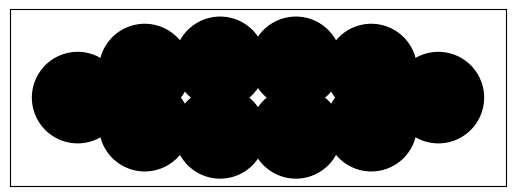

[0.17206434 0.17998202 0.18004984 0.1800587  0.18004984 0.17998202
 0.17206434 0.17206434 0.17998202 0.18004984 0.1800587  0.18004984
 0.17998202]


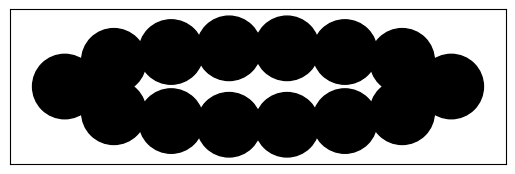

[0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237 0.07218237
 0.07218237 0.07218237 0.07218237]


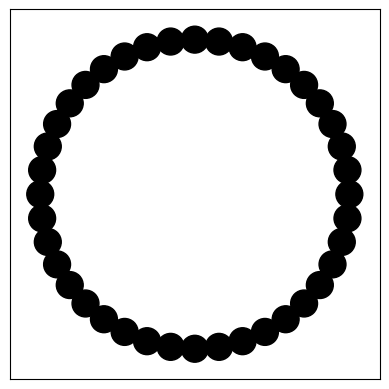

In [85]:
plot_2d_shape(
    particle_radius=0.5,
    asperity_radius=0.1,
    num_vertices=10,
    add_core=False,
    use_uniform_mesh=True,
    aspect_ratio=5.0
)
plt.savefig('figures/2d-mesh/ellipse.png', dpi=600)
plt.show()

plot_2d_shape(
    particle_radius=0.7,
    asperity_radius=0.1,
    num_vertices=14,
    add_core=False,
    use_uniform_mesh=True,
    aspect_ratio=5.0
)
plt.show()

plot_2d_shape(
    particle_radius=0.5,
    asperity_radius=0.04,
    num_vertices=40,
    add_core=False,
    use_uniform_mesh=True,
    aspect_ratio=1.0
)
plt.savefig('figures/2d-mesh/circle.png', dpi=600)
plt.show()

[0.2678784 0.2678784 0.2678784 0.2678784 0.2678784 0.2678784 0.2678784]


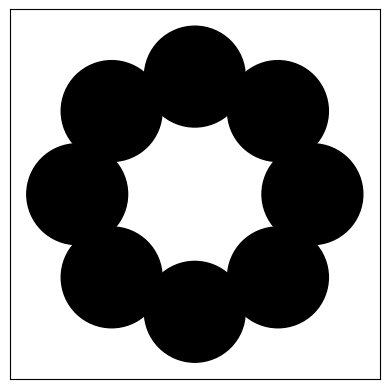

[0.24477303 0.24477303 0.24477303 0.24477303 0.24477303 0.24477303
 0.24477303 0.24477303 0.24477303 0.24477303 0.24477303 0.24477303
 0.24477303]


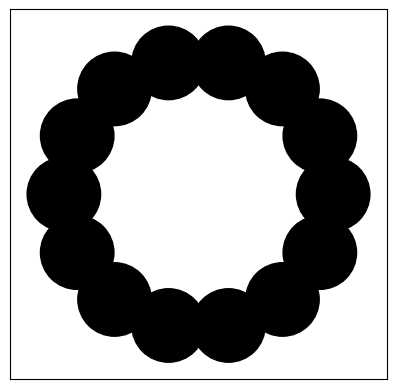

In [91]:
plot_2d_shape(
    particle_radius=0.5,
    asperity_radius=0.15,
    num_vertices=8,
    add_core=False,
    use_uniform_mesh=True,
    aspect_ratio=1.0
)
plt.show()

plot_2d_shape(
    particle_radius=0.7,
    asperity_radius=0.15,
    num_vertices=14,
    add_core=False,
    use_uniform_mesh=True,
    aspect_ratio=1.0
)
plt.show()